# Full Machine Learning Pipeline

## Job 1: ETL to Build the Warehouse
---

In [176]:
import sqlite3
import pandas as pd
import os
import sys
from pathlib import Path

jobs_path = Path().resolve() / 'jobs'
if not jobs_path.exists():
    jobs_path = Path().resolve().parent / 'jobs'

sys.path.insert(0, str(jobs_path))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)




In [177]:
#Load tables from shop.db

src = sqlite3.connect(r"C:\Users\apier\OneDrive\Documents\Code\455\project\shop.db")

orders      = pd.read_sql('SELECT * FROM orders', src)
customers   = pd.read_sql('SELECT * FROM customers', src)
shipments   = pd.read_sql('SELECT * FROM shipments', src)
order_items = pd.read_sql('''
    SELECT oi.order_id,
           oi.quantity, oi.unit_price, oi.line_total,
           p.category
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
''', src)
reviews = pd.read_sql('SELECT customer_id, rating FROM product_reviews', src)

src.close()


In [178]:
#Aggregate order_items (one row per order)

items_agg = order_items.groupby('order_id').agg(
    items_count         = ('quantity', 'count'),
    total_quantity      = ('quantity', 'sum'),
    avg_unit_price      = ('unit_price', 'mean'),
    max_unit_price      = ('unit_price', 'max'),
    min_unit_price      = ('unit_price', 'min'),
    distinct_categories = ('category', 'nunique'),
).reset_index()

cat_dummies = (
    order_items.drop_duplicates(subset=['order_id', 'category'])
    .assign(present=1)
    .pivot_table(index='order_id', columns='category', values='present', fill_value=0)
    .reset_index()
)
cat_dummies.columns = ['order_id'] + [f'cat_{c.lower()}' for c in cat_dummies.columns[1:]]

items_agg = items_agg.merge(cat_dummies, on='order_id', how='left')


In [179]:
#Aggregate reviews (one row per customer)

reviews_agg = reviews.groupby('customer_id').agg(
    customer_avg_rating   = ('rating', 'mean'),
    customer_review_count = ('rating', 'count'),
).reset_index()


In [180]:
#Join everything onto orders (one row per order, with customer, shipment, items, and review features)

df = orders.copy()

cust_cols = ['customer_id', 'gender', 'birthdate', 'created_at',
             'city', 'state', 'zip_code', 'customer_segment',
             'loyalty_tier', 'is_active']
df = df.merge(customers[cust_cols], on='customer_id', how='left')

ship_cols = [c for c in shipments.columns if c != 'shipment_id']
df = df.merge(shipments[ship_cols], on='order_id', how='left')

df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(reviews_agg, on='customer_id', how='left')
df = df.drop(columns=['is_fraud'])

print(df.shape)
df.head()


(5000, 50)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,gender,birthdate,created_at,city,state,zip_code,customer_segment,loyalty_tier,is_active,ship_datetime,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery,items_count,total_quantity,avg_unit_price,max_unit_price,min_unit_price,distinct_categories,cat_apparel,cat_automotive,cat_beauty,cat_books,cat_electronics,cat_garden,cat_grocery,cat_home,cat_sports,cat_toys,customer_avg_rating,customer_review_count
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,NaN,662.95,15.44,46.30,724.69,38.3,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-11-29 09:51:07,UPS,expedited,regional,3,5,1,5,9,69.242,99.90,23.16,4,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.583333,12
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,94.9,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-09-02 08:25:59,FedEx,expedited,local,2,3,1,5,7,133.300,241.51,47.27,3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.583333,12
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,NaN,796.09,14.04,40.72,850.85,53.8,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-12-16 13:24:41,FedEx,expedited,national,4,8,1,3,5,140.850,230.50,49.01,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.583333,12
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,WELCOME,137.60,6.99,11.88,156.47,4.2,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-11-07 21:21:19,UPS,standard,regional,6,6,0,1,1,137.600,137.60,137.60,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.583333,12
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,NaN,17.07,6.99,1.40,25.46,4.9,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2025-12-01 14:34:15,USPS,standard,regional,6,7,1,1,1,17.070,17.07,17.07,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.583333,12


In [181]:
#feature engineering
df['customer_tenure_days'] = (pd.to_datetime('today') - pd.to_datetime(df['created_at'])).dt.days
df['order_datetime'] = pd.to_datetime(df['order_datetime'])
df['birthdate']      = pd.to_datetime(df['birthdate'])
df['created_at']     = pd.to_datetime(df['created_at'])
df['customer_age'] = (pd.to_datetime('today') - df['birthdate']).dt.days // 365
df['promo_used_flag']       = df['promo_code'].notna().astype(int)



C:\Users\apier\AppData\Local\Temp\ipykernel_21952\1874730867.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_test[test_cols].select_dtypes(include='object').columns.tolist()


Encoding: ['shipping_state', 'payment_method', 'device_type', 'ip_country', 'gender', 'state', 'customer_segment', 'loyalty_tier', 'carrier', 'shipping_method', 'distance_band']


order_subtotal           0.457226
order_total              0.177343
customer_tenure_days     0.131867
customer_avg_rating      0.038048
customer_age             0.030437
tax_amount               0.021180
ip_country               0.018522
shipping_state           0.015413
state                    0.013091
max_unit_price           0.010144
avg_unit_price           0.009819
min_unit_price           0.009476
payment_method           0.009038
shipping_fee             0.005573
device_type              0.004232
promised_days            0.004038
promo_used               0.003544
promo_used_flag          0.003226
carrier                  0.003064
customer_review_count    0.002943
loyalty_tier             0.002905
distinct_categories      0.002895
total_quantity           0.002890
distance_band            0.002333
gender                   0.002292
items_count              0.002066
customer_segment         0.001939
cat_automotive           0.001549
cat_apparel              0.001528
cat_sports    

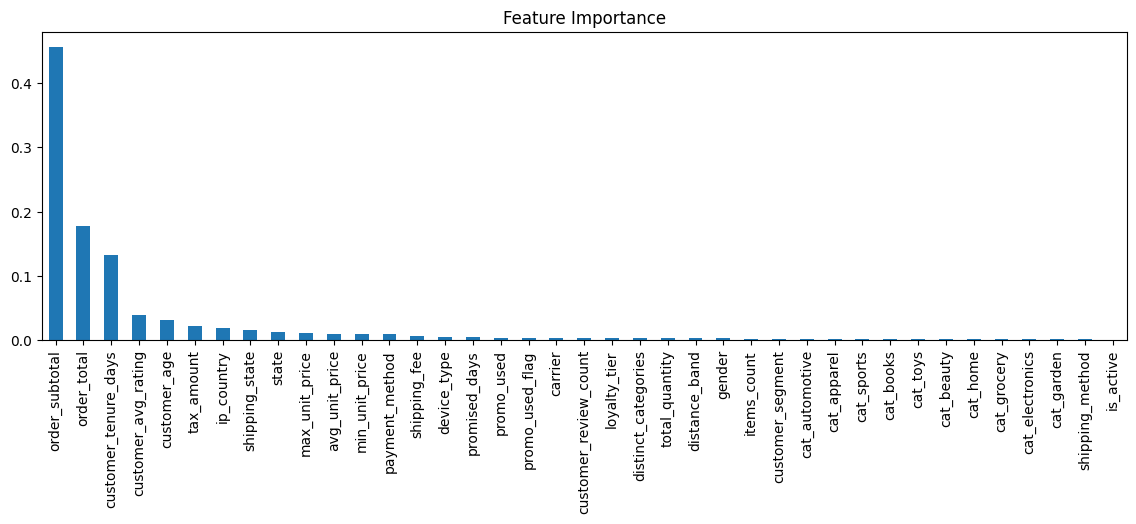

In [182]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

always_drop = [
    'order_id', 'customer_id',
    'risk_score',
    'is_fraud',
    'actual_days',
    'late_delivery',
    'order_datetime', 'ship_datetime',
    'birthdate', 'created_at',
    'promo_code',
    'billing_zip', 'shipping_zip',
    'zip_code',
    'city',
]

test_cols = [c for c in df.columns if c not in always_drop]

df_test = df[test_cols + ['risk_score']].copy().dropna()

# Encode ALL string columns
string_cols = df_test[test_cols].select_dtypes(include='object').columns.tolist()
print("Encoding:", string_cols)

for col in string_cols:
    df_test[col] = OrdinalEncoder().fit_transform(df_test[[col]])

X_test = df_test[test_cols]
y_test = df_test['risk_score']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_test, y_test)

importance = pd.Series(rf.feature_importances_, index=test_cols).sort_values(ascending=False)
importance.plot(kind='bar', figsize=(14, 4), title='Feature Importance')
importance


In [183]:
threshold = 0.01
selected_features = importance[importance >= threshold].index.tolist()
dropped_features  = importance[importance < threshold].index.tolist()

print("Keeping:", selected_features)
print("Dropping:", dropped_features)
print(f"Selected {len(selected_features)} features covering {importance[selected_features].sum():.1%} of total importance")



Keeping: ['order_subtotal', 'order_total', 'customer_tenure_days', 'customer_avg_rating', 'customer_age', 'tax_amount', 'ip_country', 'shipping_state', 'state', 'max_unit_price']
Dropping: ['avg_unit_price', 'min_unit_price', 'payment_method', 'shipping_fee', 'device_type', 'promised_days', 'promo_used', 'promo_used_flag', 'carrier', 'customer_review_count', 'loyalty_tier', 'distinct_categories', 'total_quantity', 'distance_band', 'gender', 'items_count', 'customer_segment', 'cat_automotive', 'cat_apparel', 'cat_sports', 'cat_books', 'cat_toys', 'cat_beauty', 'cat_home', 'cat_grocery', 'cat_electronics', 'cat_garden', 'shipping_method', 'is_active']
Selected 10 features covering 91.3% of total importance


In [184]:
df = df[selected_features + ['risk_score']].copy()

In [185]:
same = (df['state'] == df['shipping_state']).mean()
print(f"state == shipping_state: {same:.1%} of the time")


state == shipping_state: 92.8% of the time


In [186]:
df = df.drop(columns=['state'])

In [187]:
#Write to warehouse.db

if os.path.exists('warehouse.db'):
    os.remove('warehouse.db')

dst = sqlite3.connect('warehouse.db')
df.to_sql('orders_denorm', dst, index=False, if_exists='replace')
dst.close()

print('warehouse.db written — table: orders_denorm')


warehouse.db written — table: orders_denorm


In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_subtotal        5000 non-null   float64
 1   order_total           5000 non-null   float64
 2   customer_tenure_days  5000 non-null   int64  
 3   customer_avg_rating   5000 non-null   float64
 4   customer_age          5000 non-null   int64  
 5   tax_amount            5000 non-null   float64
 6   ip_country            5000 non-null   str    
 7   shipping_state        5000 non-null   str    
 8   max_unit_price        5000 non-null   float64
 9   risk_score            5000 non-null   float64
dtypes: float64(6), int64(2), str(2)
memory usage: 390.8 KB


## Job 2: Train the Model and Save the Artifacts
---

In [189]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("warehouse.db")

# Load the modeling table created by the ETL step
df = pd.read_sql("SELECT * FROM orders_denorm", conn)
conn.close()

print(df.shape)
df.head()

(5000, 10)


,order_subtotal,order_total,customer_tenure_days,customer_avg_rating,customer_age,tax_amount,ip_country,shipping_state,max_unit_price,risk_score
0,662.95,724.69,172,2.583333,20,46.30,US,CO,99.90,38.3
1,862.92,944.27,172,2.583333,20,66.61,US,NY,241.51,94.9
2,796.09,850.85,172,2.583333,20,40.72,US,CO,230.50,53.8
3,137.60,156.47,172,2.583333,20,11.88,US,CO,137.60,4.2
4,17.07,25.46,172,2.583333,20,1.40,CA,CO,17.07,4.9


In [190]:
from sklearn.model_selection import train_test_split

label_col = "risk_score"

feature_cols = [
    c for c in df.columns
    if c != label_col
]

X = df[feature_cols]
y = df[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=27,
)

X_train.shape, X_test.shape

((4000, 9), (1000, 9))

In [191]:
# Identify feature types using training data only
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

num_cols, cat_cols

# Output:
# (Index(['age', 'bmi', 'children'], dtype='object'),
# Index(['sex', 'smoker', 'region'], dtype='object'))

C:\Users\apier\AppData\Local\Temp\ipykernel_21952\2762986761.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


(Index(['order_subtotal', 'order_total', 'customer_tenure_days',
        'customer_avg_rating', 'customer_age', 'tax_amount', 'max_unit_price'],
       dtype='str'),
 Index(['ip_country', 'shipping_state'], dtype='str'))

In [192]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_preprocess = Pipeline(steps=[
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
("imputer", SimpleImputer(strategy="most_frequent")),
("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
transformers=[
    ("num", numeric_preprocess, num_cols),
    ("cat", categorical_preprocess, cat_cols)
]
)

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

X_train_ready.shape, X_test_ready.shape


((4000, 31), (1000, 31))

In [193]:
from sklearn.linear_model import LinearRegression

# Extend the existing preprocessing pipeline with a regression model
predictive_model = Pipeline(steps=[
("prep", preprocessor),
("lr", LinearRegression())
])

# Fit only on training data
predictive_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [194]:
# Generate predictions for the test set
y_pred = predictive_model.predict(X_test)

# Preview first 5 predictions
y_pred[:5]

array([ 72.57476422,  54.23808785,  40.19470148,  35.46536495,
       -10.27128269])

In [195]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline predictor: mean of training labels
baseline_value = y_train.mean()
y_pred_baseline = np.full_like(y_test, fill_value=baseline_value, dtype=float)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline MAE:  {baseline_mae:,.2f}")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Baseline R²:   {baseline_r2:.4f}")

Baseline MAE:  21.61
Baseline RMSE: 25.95
Baseline R²:   -0.0054


In [196]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

model_mae  = mean_absolute_error(y_test, y_pred)
model_rmse = root_mean_squared_error(y_test, y_pred)
model_r2   = r2_score(y_test, y_pred)

print(f"Model MAE:  {model_mae:.2f}")
print(f"Model RMSE: {model_rmse:.2f}")
print(f"Model R²:   {model_r2:.4f}")

Model MAE:  10.33
Model RMSE: 13.07
Model R²:   0.7451


Train RMSE: 13.16  |  Test RMSE: 13.07
Train R²:   0.7756  |  Test R²:   0.7451
Test MAE:   10.33

RMSE % diff:  -0.7%  ✓ ok
R² gap:       0.0306  ✓ ok
RMSE ratio:   0.993  ✓ ok


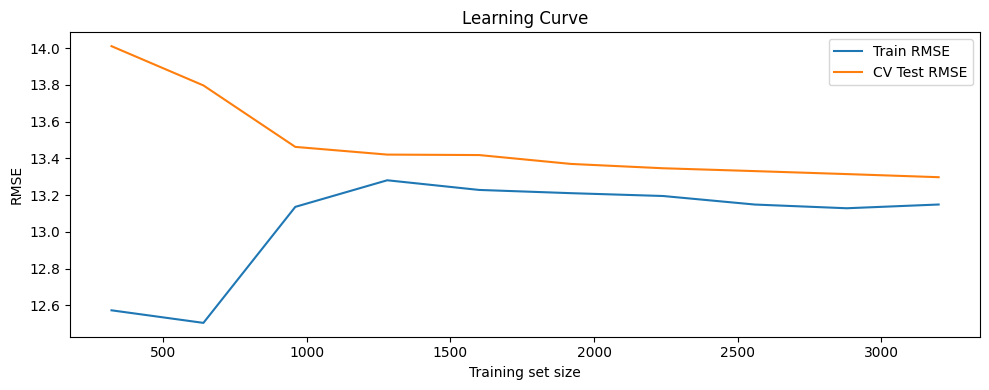


CV RMSE per fold: [np.float64(13.46), np.float64(13.56), np.float64(13.37), np.float64(12.87), np.float64(13.24)]
CV Mean: 13.30  |  Std: 0.24  ✓ consistent


In [197]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- Train metrics ---
y_train_pred = predictive_model.predict(X_train)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_r2   = r2_score(y_train, y_train_pred)

# --- Test metrics ---
y_pred     = predictive_model.predict(X_test)
test_rmse  = root_mean_squared_error(y_test, y_pred)
test_r2    = r2_score(y_test, y_pred)
test_mae   = mean_absolute_error(y_test, y_pred)

print(f"Train RMSE: {train_rmse:.2f}  |  Test RMSE: {test_rmse:.2f}")
print(f"Train R²:   {train_r2:.4f}  |  Test R²:   {test_r2:.4f}")
print(f"Test MAE:   {test_mae:.2f}")
print()

# --- Heuristic 1: RMSE % difference ---
rmse_pct_diff = (test_rmse - train_rmse) / train_rmse * 100
print(f"RMSE % diff:  {rmse_pct_diff:.1f}%  {'⚠ possible overfit' if rmse_pct_diff > 10 else '✓ ok'}")

# --- Heuristic 2: R² gap ---
r2_gap = train_r2 - test_r2
print(f"R² gap:       {r2_gap:.4f}  {'⚠ possible overfit' if r2_gap > 0.10 else '✓ ok'}")

# --- Heuristic 3: RMSE ratio ---
rmse_ratio = test_rmse / train_rmse
print(f"RMSE ratio:   {rmse_ratio:.3f}  {'⚠ possible overfit' if rmse_ratio > 1.2 else '✓ ok'}")

# --- Heuristic 4: Learning curve ---
train_sizes, train_scores, test_scores = learning_curve(
    predictive_model, X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse_curve = -train_scores.mean(axis=1)
test_rmse_curve  = -test_scores.mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(train_sizes, train_rmse_curve, label='Train RMSE')
plt.plot(train_sizes, test_rmse_curve,  label='CV Test RMSE')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

# --- Heuristic 5: Cross-validation consistency ---
cv_scores = cross_val_score(predictive_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse   = -cv_scores
print(f"\nCV RMSE per fold: {[round(s, 2) for s in cv_rmse]}")
print(f"CV Mean: {cv_rmse.mean():.2f}  |  Std: {cv_rmse.std():.2f}  {'⚠ high variance' if cv_rmse.std() > 2 else '✓ consistent'}")


In [198]:
import joblib

joblib.dump(predictive_model, "risk_score_model.sav")

['risk_score_model.sav']

In [199]:
import json
from datetime import datetime

model_version = "1.0.0"

metadata = {
"model_name": "risk_score_model",
"model_version": model_version,
"trained_at_utc": datetime.utcnow().isoformat(),
"warehouse_table": "fact_orders_ml",
"num_training_rows": int(X_train.shape[0]),
"num_test_rows": int(X_test.shape[0]),
"features": feature_cols
}

metrics = {
"train_rmse": train_rmse,
"train_r2": train_r2,
"test_rmse": test_rmse,
"test_r2": test_r2,
"test_mae": test_mae
}

with open("model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

with open("metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

C:\Users\apier\AppData\Local\Temp\ipykernel_21952\1372779467.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at_utc": datetime.utcnow().isoformat(),


## Job 3: Run Inference and Write Predictions to `shop.db`
---

In [200]:
import joblib

model = joblib.load("risk_score_model.sav")
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [202]:
conn = sqlite3.connect(r"C:\Users\apier\OneDrive\Documents\Code\455\project\shop.db")

query = """
SELECT
    o.order_id,
    o.order_subtotal,
    o.order_total,
    o.tax_amount,
    o.shipping_state,
    o.ip_country,
    c.customer_id,
    c.birthdate,
    c.created_at,
    r.avg_rating AS customer_avg_rating,
    oi.max_unit_price
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN (
    SELECT customer_id, AVG(rating) AS avg_rating
    FROM product_reviews
    GROUP BY customer_id
) r ON r.customer_id = c.customer_id
LEFT JOIN (
    SELECT order_id, MAX(unit_price) AS max_unit_price
    FROM order_items
    GROUP BY order_id
) oi ON oi.order_id = o.order_id
"""

df_live = pd.read_sql(query, conn)
df_live.head()


,order_id,order_subtotal,order_total,tax_amount,shipping_state,ip_country,customer_id,birthdate,created_at,customer_avg_rating,max_unit_price
0,1,662.95,724.69,46.30,CO,US,1,2005-06-08,2025-10-11 16:37:40,2.583333,99.90
1,2,862.92,944.27,66.61,NY,US,1,2005-06-08,2025-10-11 16:37:40,2.583333,241.51
2,3,796.09,850.85,40.72,CO,US,1,2005-06-08,2025-10-11 16:37:40,2.583333,230.50
3,4,137.60,156.47,11.88,CO,US,1,2005-06-08,2025-10-11 16:37:40,2.583333,137.60
4,5,17.07,25.46,1.40,CO,CA,1,2005-06-08,2025-10-11 16:37:40,2.583333,17.07


In [203]:
from datetime import datetime

df_live['customer_tenure_days'] = (pd.to_datetime('today') - pd.to_datetime(df_live['created_at'])).dt.days
df_live['customer_age'] = (pd.to_datetime('today') - pd.to_datetime(df_live['birthdate'])).dt.days // 365

# Historical order count per customer
order_counts = (
df_live.groupby("customer_id")["order_id"]
    .transform("count")
)

df_live["customer_order_count"] = order_counts

feature_cols = [
    'order_subtotal', 'order_total', 'tax_amount',
    'shipping_state', 'ip_country',
    'customer_age', 'customer_tenure_days', 'customer_avg_rating',
    'max_unit_price'
]

X_live = df_live[feature_cols]

In [206]:
df_live["predicted_risk_score"] = predictive_model.predict(X_live)

df_live[["order_id", "predicted_risk_score"]].head()


,order_id,predicted_risk_score
0,1,61.180051
1,2,72.574764
2,3,67.609262
3,4,20.425869
4,5,25.916072


In [208]:
from datetime import datetime

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS order_predictions_risk (
    order_id              INTEGER PRIMARY KEY,
    predicted_risk_score  REAL,
    prediction_timestamp  TEXT
)
""")

rows = [
    (
        int(row.order_id),
        float(row.predicted_risk_score),
        datetime.utcnow().isoformat()
    )
    for row in df_live.itertuples()
]

cursor.executemany("""
INSERT OR REPLACE INTO order_predictions_risk
(order_id, predicted_risk_score, prediction_timestamp)
VALUES (?, ?, ?)
""", rows)

conn.commit()
conn.close()

print(f"Predictions written: {len(rows)}")


Predictions written: 5000


C:\Users\apier\AppData\Local\Temp\ipykernel_21952\263379565.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat()
